In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../dataset/zameen-updated.csv")
df.head()


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [5]:
df.shape

(168446, 20)

In [6]:
df.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [8]:
df = df.drop([
    'property_id',
    'page_url',
    'date_added',
    'agency',
    'agent',
    'latitude','longitude','purpose','location_id','province_name','Area Type','Area Category'
], axis=1)

In [9]:
df.head()

,property_type,price,location,city,baths,area,bedrooms,Area Size
0,Flat,10000000,G-10,Islamabad,2,4 Marla,2,4.0
1,Flat,6900000,E-11,Islamabad,3,5.6 Marla,3,5.6
2,House,16500000,G-15,Islamabad,6,8 Marla,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,2 Kanal,4,2.0
4,House,7000000,DHA Defence,Islamabad,3,8 Marla,3,8.0


In [10]:
df.isnull().sum()

property_type    0
price            0
location         0
city             0
baths            0
area             0
bedrooms         0
Area Size        0
dtype: int64

In [11]:
df=df.dropna()
df.dtypes
df.shape

(168446, 8)

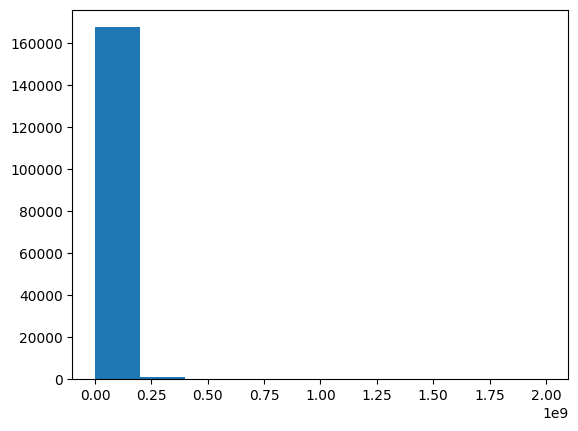

In [12]:
plt.hist(df['price'])
plt.show()

In [13]:
df = df[df['price'] < df['price'].quantile(0.99)]
df.shape

(166686, 8)

In [14]:
# CHANGED: convert area to numeric sqft using Area Size (already numeric)
# Kanal rows get multiplied by 20 to convert to Marla, then * 225 for sqft
def convert_area_to_marla(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    try:
        if "kanal" in x:
            value = float(x.replace("kanal", "").strip())
            return value * 20

        if "marla" in x:
            return float(x.replace("marla", "").strip())

        # if already numeric
        return float(x)

    except:
        return np.nan

# convert area properly
df['area_marla'] = df['area'].apply(convert_area_to_marla)

# drop old columns
df = df.drop(['area'], axis=1)

# remove missing values
df = df.dropna(subset=['area_marla'])
df["area_marla"] = np.log1p(df["area_marla"])

In [15]:
# CHANGED: remove junk data - prices below 500k are clearly errors/rentals
# (data had prices like 0, 1, 3, 4 which destroy the model)
df = df[df['price'] >= 500000]

# Also remove junk area values
df = df[df['area_marla'] > 0]
df = df[df['area_marla'] < df['area_marla'].quantile(0.99)]

# Remove zero baths/bedrooms (bad data)
df = df[df['baths'] > 0]
df = df[df['bedrooms'] > 0]

print(df.shape)

(91476, 8)


In [16]:
features = ['city', 'location','property_type', 'area_marla', 'bedrooms', 'baths']
target   = 'price'

df = df[features + [target]].dropna()

In [17]:
df = df.dropna()

In [18]:
df.shape

(91476, 7)

In [19]:
# CHANGED: split FIRST before any encoding (prevents data leakage)
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# CHANGED: mean encode location using ONLY train data (no leakage)
loc_mean = y_train.groupby(X_train['location']).mean()

X_train = X_train.copy()
X_test = X_test.copy()

X_train['location_encoded'] = X_train['location'].map(loc_mean).fillna(y_train.mean())
X_test['location_encoded'] = X_test['location'].map(loc_mean).fillna(y_train.mean())

X_train = X_train.drop('location', axis=1)
X_test = X_test.drop('location', axis=1)

In [21]:
# CHANGED: only city and property_type get one-hot encoded (location already handled)
X_train = pd.get_dummies(X_train, columns=['city', 'property_type'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['city', 'property_type'], drop_first=True)

# align columns in case test is missing any category
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
     n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
score = rf.score(X_test, y_test)

print(score)

0.8393944243068336


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.83472403 0.84765416 0.84225808 0.86137311 0.85029866]
0.8472616100018874


In [26]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9095931239304247
0.8393944243068336


In [31]:
import joblib

joblib.dump(rf, "house_price_model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [32]:
y_pred = rf.predict(X_test)

In [33]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

import numpy as np

comparison["Actual_price"] = np.expm1(comparison["Actual"])
comparison["Predicted_price"] = np.expm1(comparison["Predicted"])



print(comparison.head(20))

           Actual  Predicted  Actual_price  Predicted_price
27887   18.538464  18.481894   112500000.0     1.063125e+08
88220   14.845130  15.007669     2800000.0     3.294184e+06
100065  15.640060  15.633614     6200000.0     6.160161e+06
97885   16.454568  16.690744    14000000.0     1.772957e+07
98505   16.380460  16.499981    13000000.0     1.465043e+07
101259  16.860033  16.490150    21000000.0     1.450712e+07
74636   15.732433  15.608651     6800000.0     6.008291e+06
145873  15.640060  15.604662     6200000.0     5.984371e+06
113078  17.909855  17.683100    60000000.0     4.782696e+07
30354   17.504390  17.736708    40000000.0     5.046082e+07
136759  16.835935  16.813179    20500000.0     2.003876e+07
146393  16.380460  16.255144    13000000.0     1.146883e+07
51931   15.761421  15.571936     7000000.0     5.791695e+06
40427   16.523561  16.504459    15000000.0     1.471619e+07
33612   16.012735  16.322875     9000000.0     1.227254e+07
108557  16.257858  16.192092    11500000

In [34]:
# 1. Exact column order scaler was trained on
print(scaler.feature_names_in_.tolist())

['area_marla', 'bedrooms', 'baths', 'location_encoded', 'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Rawalpindi', 'property_type_Flat', 'property_type_House', 'property_type_Lower Portion', 'property_type_Penthouse', 'property_type_Room', 'property_type_Upper Portion']
